In [7]:
import pandas as pd

In [10]:
df = pd.read_excel("/pivot.xls", skiprows=4)

In [11]:
df = df.set_index(df.columns[1])

In [12]:
df = df.iloc[:, 2:]

In [13]:
df_temiz = df.T

In [14]:
print("Yeni Veri Setinin Boyutu:", df_temiz.shape)
print(df_temiz.head())

Yeni Veri Setinin Boyutu: (81, 4)
1. (Uzman Hekim)  2. (Pratisyen Hekim)  5. (Hemşire)  6. (Ebe)  Ölçüm bazında
2971                              1384          6921      1722            316
403                                439          1929       675            176
713                                496          2381       587            317
361                                308          1199       355            256
306                                265          1066       338            277


In [15]:
from sklearn.preprocessing import StandardScaler

df_temiz = df_temiz.apply(pd.to_numeric, errors='coerce')

df_temiz = df_temiz.fillna(df_temiz.mean())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_temiz)

print("Veri başarıyla sayısallaştırıldı ve ölçeklendirildi!")

Veri başarıyla sayısallaştırıldı ve ölçeklendirildi!


In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)


df_temiz['Kume'] = kmeans.fit_predict(X_scaled)

print("Kümeleme işlemi başarıyla tamamlandı!\n")

print(df_temiz[['Kume']].head(10))

Kümeleme işlemi başarıyla tamamlandı!

1. (Uzman Hekim)  Kume
2971                 0
403                  2
713                  2
361                  2
306                  2
12064                0
4033                 0
72                   2
138                  2
1350                 2


In [17]:

kume_ozet = df_temiz.groupby('Kume').mean()

print("KÜMELERİN ORTALAMA DEĞERLERİ:")
print(kume_ozet)
print("-" * 50)

print("\nHANGİ KÜMEDE KAÇ İL VAR?")
print(df_temiz['Kume'].value_counts())

KÜMELERİN ORTALAMA DEĞERLERİ:
1. (Uzman Hekim)  2. (Pratisyen Hekim)  5. (Hemşire)     6. (Ebe)  \
Kume                                                                
0                           955.750000   5188.833333  1134.000000   
1                          9185.000000  45229.000000  7252.000000   
2                           407.428571   1698.142857   484.821429   

1. (Uzman Hekim)  Ölçüm bazında  
Kume                             
0                    399.916667  
1                    300.000000  
2                    256.750000  
--------------------------------------------------

HANGİ KÜMEDE KAÇ İL VAR?
Kume
2    56
0    24
1     1
Name: count, dtype: int64


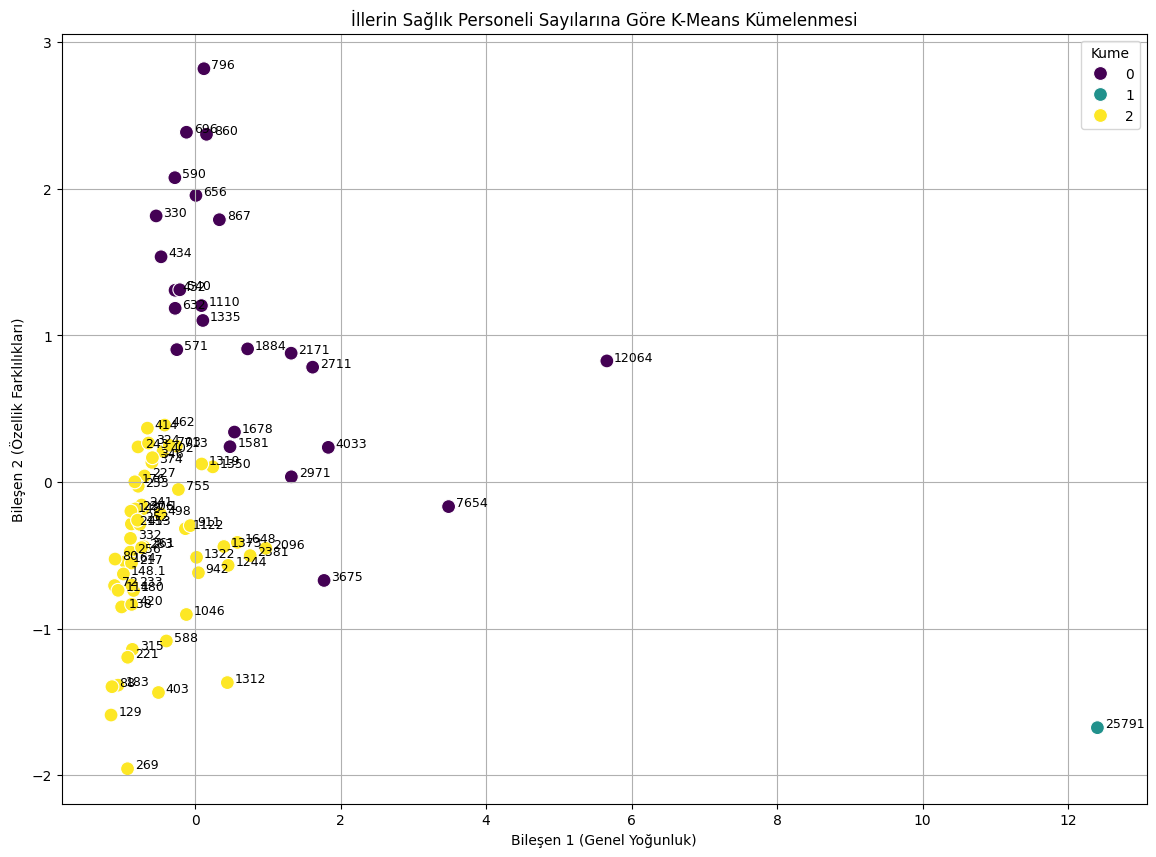

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_temiz['PCA1'] = X_pca[:, 0]
df_temiz['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(14, 10))
sns.scatterplot(x='PCA1', y='PCA2', hue='Kume', data=df_temiz, palette='viridis', s=100)

for i, il in enumerate(df_temiz.index):
    plt.text(df_temiz['PCA1'].iloc[i] + 0.1, df_temiz['PCA2'].iloc[i], il, fontsize=9)

plt.title("İllerin Sağlık Personeli Sayılarına Göre K-Means Kümelenmesi")
plt.xlabel("Bileşen 1 (Genel Yoğunluk)")
plt.ylabel("Bileşen 2 (Özellik Farklılıkları)")
plt.grid(True)
plt.show()

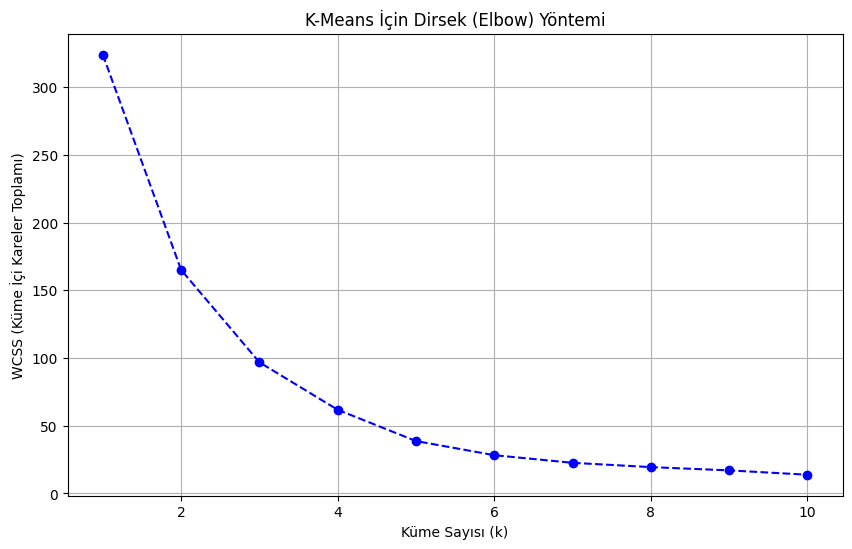

In [24]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('K-Means İçin Dirsek (Elbow) Yöntemi')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('WCSS (Küme İçi Kareler Toplamı)')
plt.grid(True)
plt.show()

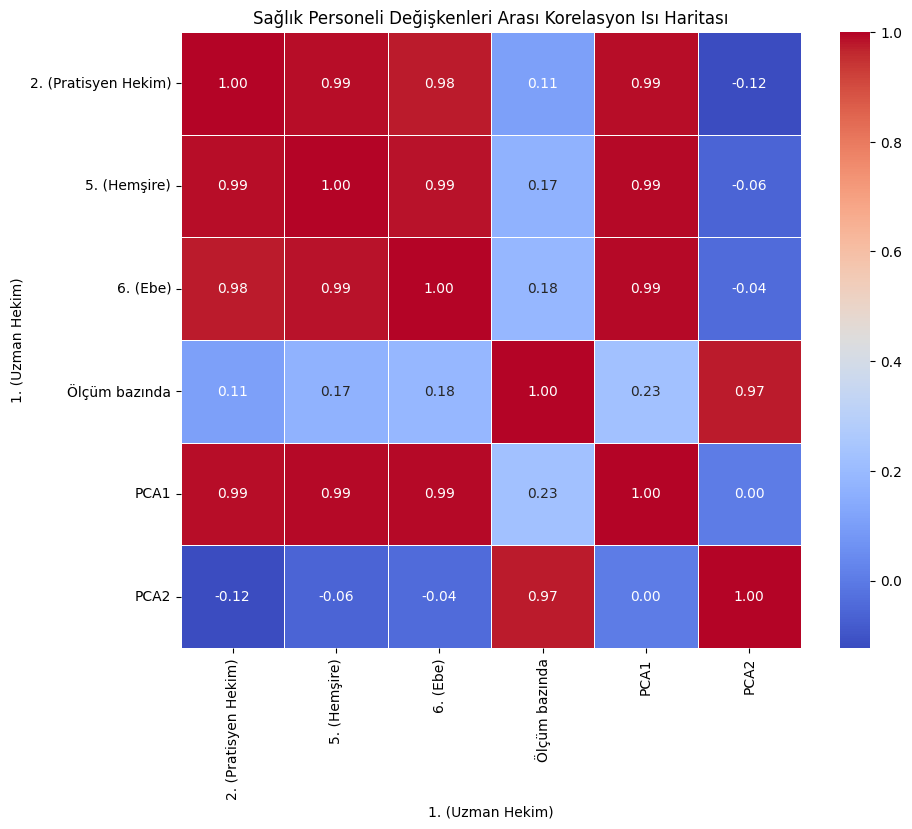

In [30]:
import seaborn as sns

plt.figure(figsize=(10, 8))
korelasyon_matrisi = df_temiz.drop('Kume', axis=1, errors='ignore').corr()

sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Sağlık Personeli Değişkenleri Arası Korelasyon Isı Haritası')
plt.show()

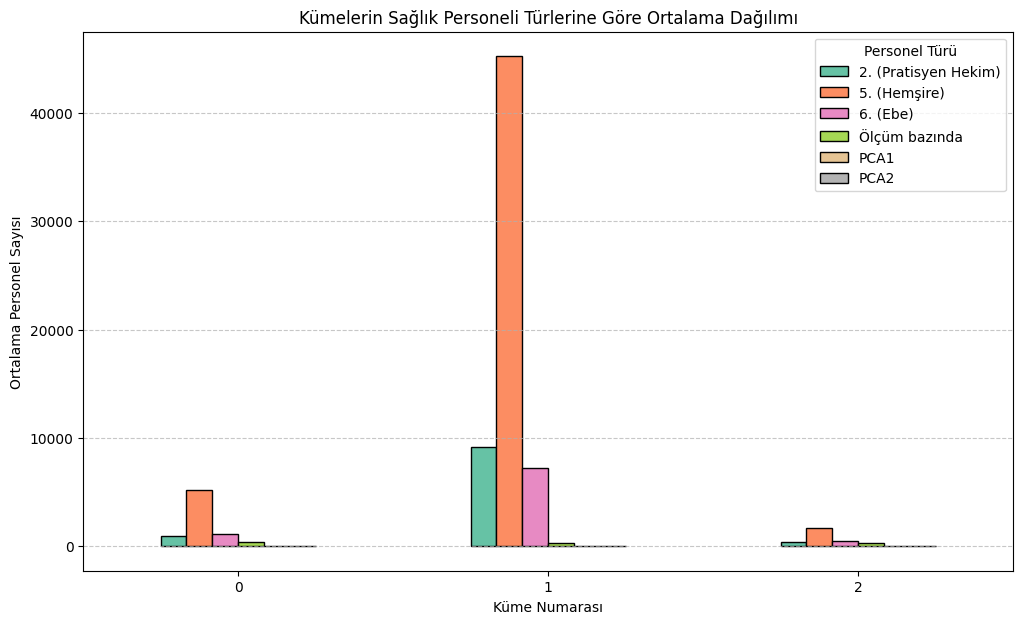

In [31]:

kume_ortalamalari = df_temiz.groupby('Kume').mean()

kume_ortalamalari.plot(kind='bar', figsize=(12, 7), colormap='Set2', edgecolor='black')
plt.title('Kümelerin Sağlık Personeli Türlerine Göre Ortalama Dağılımı')
plt.xlabel('Küme Numarası')
plt.ylabel('Ortalama Personel Sayısı')
plt.xticks(rotation=0)
plt.legend(title='Personel Türü')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [32]:

df_temiz.to_excel("KumelemeSonuclari.xlsx")

print("Sonuçlar başarıyla bilgisayara kaydedildi!")

Sonuçlar başarıyla bilgisayara kaydedildi!
